In [1]:
import tmdc_optics_tools as tmdc
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
geom = tmdc.DeviceGeometry(
    tmdc_stack = [tmdc.StackLayer("WSe2"), tmdc.StackLayer("WSe2")],
    d_hbn_top = 36.9,
    d_hbn_bottom = 33.9,
    label = "hBN/2L-WSe2/hBN"
)

In [3]:
filepath = Path("./data/2L-WSe2-PL/2L_WSe2_FieldSweep.csv")
scan = tmdc.BigTableSpectralSweep(
    path = filepath,
    geometry = geom,
    sweep = "electric_field",
    spectra_type = "PL",
    bg_region_eV = [1.39, 1.41],
    cosmic_rays = {"max_iter" : 5, "sigma_threshold" : 10, "median_window": 23, "cross_sweep_veto" : True},
    gates = {
        "top"     : "Gate Voltage 2",
        "bottom"  : "Gate Voltage 1",
    }
)

C:\Users\Brandon\AppData\Local\Temp\ipykernel_39516\3949705354.py:2: UserWarning: The two signal columns of 'data\2L-WSe2-PL\2L_WSe2_FieldSweep.csv' disagree — at pixel 0, sweep point 0, column 3 reads np.float64(18.0) and column 4 reads np.float64(4.0). They are identical in every file this loader was established from, so the fourth was taken to be a copy and only the third is read as 'spectra'. A disagreement means it is not a copy: check what the acquisition program writes there before trusting this scan.
  scan = tmdc.BigTableSpectralSweep(


(<Figure size 600x400 with 2 Axes>,
 <Axes: xlabel='Energy (eV)', ylabel='$E_F$ (mV/nm)'>,
 <matplotlib.collections.QuadMesh at 0x2c4fcf85f70>)

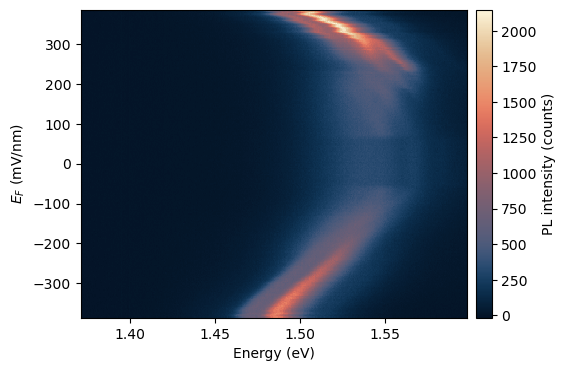

In [4]:
tmdc.plotting.plot_spectral_map(scan, cmap = "cmc.lipari")

In [7]:
# Track peak energy across the full field sweep
track = tmdc.fitting.track_peak_energies(scan, x_range=(1.43, 1.57))
print(track)

PeakTrack
  Method        : argmax
  Sweep points  : 251
  Peak range    : 1.4845 – 1.5621 eV
  Field axis    : available (251 points)
  Converged     : 251 / 251


PeakTrackPlot(fig=<Figure size 500x350 with 1 Axes>, ax=<Axes: xlabel='Peak energy (eV)', ylabel='$E_F$ (mV/nm)'>, scatter=<matplotlib.collections.PathCollection object at 0x000002C48014F3E0>)

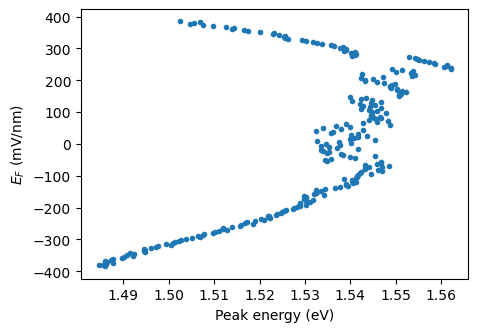

In [9]:
# Visualise peak energy vs. electric field — inspect to choose dipole ranges
tmdc.plotting.plot_peak_track(track, x_axis="energy")

In [10]:
# Extract dipole lengths from 4 linear regimes (same ranges as Peimyoo et al., Nat. Photon. 2023, Fig. 1f)
result = tmdc.fitting.extract_dipole_lengths(
    track,
    index_ranges=[(2, 62), (79, 106), (176, 191), (224, 250)],
)
print(result)

MultiDipoleResult (4 segments, track method: argmax)
  Segment 0 : d = 0.2499 ± 0.0025 nm  (2.50 Å)  R² = 0.9941  [idx: 2–62]
  Segment 1 : d = 0.1196 ± 0.0121 nm  (1.20 Å)  R² = 0.7898  [idx: 79–106]
  Segment 2 : d = 0.1734 ± 0.0226 nm  (1.73 Å)  R² = 0.8086  [idx: 176–191]
  Segment 3 : d = 0.4341 ± 0.0115 nm  (4.34 Å)  R² = 0.9829  [idx: 224–250]


(-400.0, 400.0)

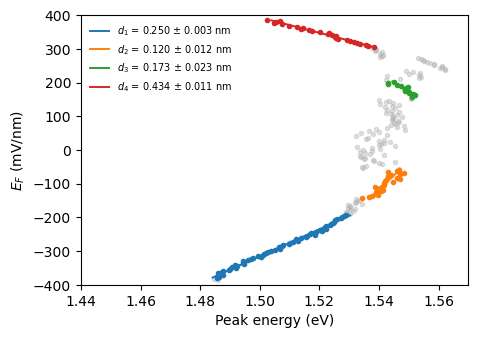

In [11]:
# Plot peak energy vs. field with linear fits per regime (cf. Fig. 1f)
fig, ax, scatter, lines = tmdc.plotting.plot_multi_stark_shift(result, x_axis="energy")
ax.set_xlim(1.44, 1.57)
ax.set_ylim(-400, 400)

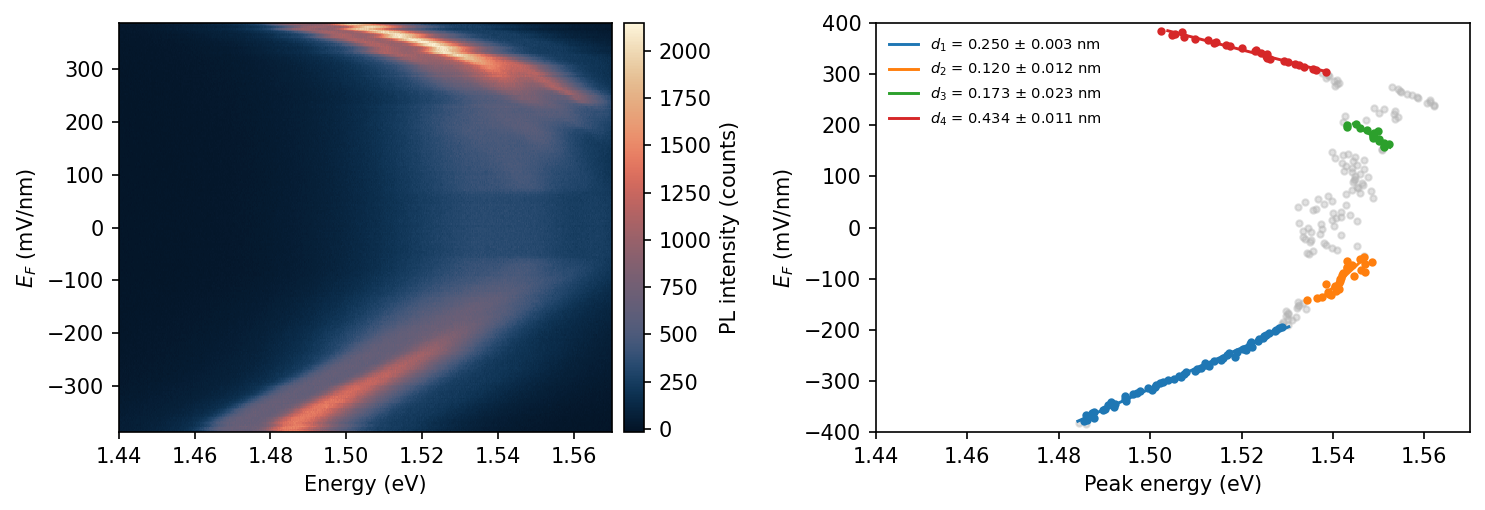

In [12]:
# Side-by-side: spectral map + Stark shift (cf. paper Fig. 1e + 1f)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5), dpi=150)

tmdc.plotting.plot_spectral_map(scan, x_axis="energy", ax=ax1, cmap="cmc.lipari")
ax1.set_xlim(1.44, 1.57)

tmdc.plotting.plot_multi_stark_shift(result, x_axis="energy", ax=ax2)
ax2.set_xlim(1.44, 1.57)
ax2.set_ylim(-400, 400)

fig.tight_layout()